# Stimulus omission responses at different flash rates

This notebook generates the plots for Supplementary Figure 8 & 9 & 10, which showcases the omission stimulus responses of the model at different flash rates.

In [55]:
#import packages
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from retina import analysis, train

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
clean_up_garbage = True #run this if have memory problems
if clean_up_garbage:
    import gc
    import torch

    # Force garbage collection
    gc.collect()

    torch.cuda.empty_cache()
    

In [57]:
#set path and run osr

#set path
root = os.path.expanduser("~/PycharmProjects/RetinalModel")

#run omission stimulus response
osr_query_set = analysis.OSRQuerySet(root, ablate_recurrence=False)
osr_query_set_ablated = analysis.OSRQuerySet(root, ablate_recurrence=True)
#note smoothing in firing_rate and smooth_input_current is important

In [58]:
#plot osr
def get_last_flash_onset(ors_query, units='ms'):
    flash_train = ors_query.flash_clip
    indexes_of_negatives = np.where(np.diff(flash_train) < 0)[0]
    last_flash_onset = indexes_of_negatives[-1] + 1  # +1 to get the actual onset index

    if units == 'ms':
        return last_flash_onset * 4.333
    elif units == 'time_bins':
        return last_flash_onset
    else:
        raise ValueError("units must be either 'ms' or 'time_bins'")

def plot_osr(ors_query, intesity_ax, max_r, idx, d, firing_ax, plot_latency=False, input_current=False):

    last_flash_onset = get_last_flash_onset(ors_query,'time_bins')
    
    intesity_ax.plot(ors_query.flash_clip, c="black", linewidth=2)
    intesity_ax.spines["top"].set_visible(False)
    intesity_ax.spines["right"].set_visible(False)
    intesity_ax.spines["bottom"].set_visible(False)
    intesity_ax.spines["left"].set_linewidth(2)
    
    fs = 14
    intesity_ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    intesity_ax.set_yticks([0, 1])
    intesity_ax.set_xlim([0, len(ors_query.flash_clip)])
    intesity_ax.set_xticks([])
    intesity_ax.set_xticklabels([])
    intesity_ax.set_xlabel("")
    
    firing_ax.plot([last_flash_onset, last_flash_onset], [0, 1], "--", c="black", linewidth=2)
    firing_ax.plot([388-d, 388-d], [0, 1], "--", c="black", linewidth=2)

    color = 'blue'
    if input_current:
        input_current = ors_query.smooth_input_current[idx]
        firing_ax.plot(input_current, linewidth=3, c=color)
    else:
        firing_rate = ors_query.firing_rate[idx]
        firing_ax.plot(firing_rate, linewidth=3, c=color)

    firing_ax.set_xticks([0, 36, 36+120, 36+2*120, 36+3*120])
    firing_ax.set_xticklabels(["", "0", "0.5", "1.0", "1.5"]) 
    
    firing_ax.spines["top"].set_visible(False)
    firing_ax.spines["right"].set_visible(False)
    firing_ax.spines["bottom"].set_linewidth(2)
    firing_ax.spines["left"].set_linewidth(2)
    firing_ax.set_xlim([0, len(ors_query.flash_clip)])
    firing_ax.set_ylim([0., 1.1*max_r])
    firing_ax.set_yticks([0, max_r])
    firing_ax.set_yticklabels(["0", f"{int(max_r * (240))}"])
    firing_ax.xaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    firing_ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    firing_ax.set_xlabel("Time (s)", fontsize=fs, labelpad=8)
    firing_ax.set_ylabel("Firing rate (Hz)", fontsize=fs, labelpad=10)
    
    return last_flash_onset*4.333

## 12Hz OSR

In [59]:
ors_query_12hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=12)

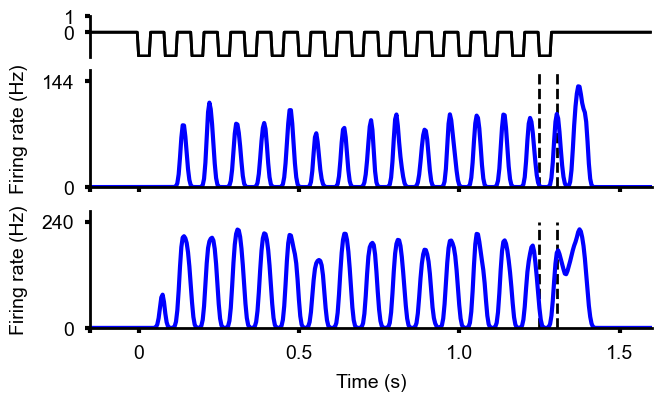

In [60]:
#Plot 12Hz OSR
#Colours need adjusting

fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1
plot_osr(ors_query_12hz, intesity_ax, 0.6, 21, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_12hz, intesity_ax, 1, 349, d, firing2_ax)
plt.savefig(f"{root}/figures/supp/16hz.svg", format="svg", transparent=False, bbox_inches="tight")

## 16Hz OSR

In [61]:
ors_query_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16)

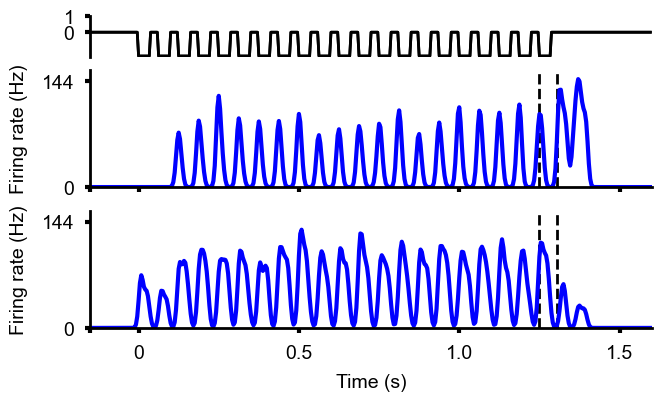

In [64]:
#Plot 16Hz OSR
#Colours need adjusting

fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1
plot_osr(ors_query_16hz, intesity_ax, 0.6, 21, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_16hz, intesity_ax, 0.6, 393, d, firing2_ax)
plt.savefig(f"{root}/figures/supp/16hz.svg", format="svg", transparent=False, bbox_inches="tight")

## 8Hz OSR

In [65]:
osr_query_8hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=8)

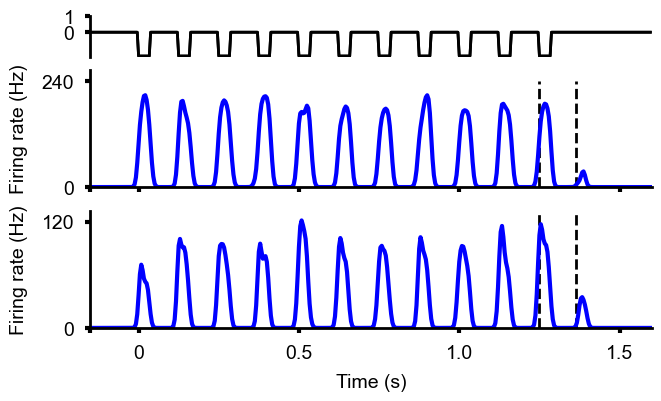

In [66]:
#Plot 16Hz OSR
#Colours need adjusting

fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-30+9+1+1
plot_osr(osr_query_8hz, intesity_ax, 1, 253, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(osr_query_8hz, intesity_ax, 0.5, 393, d, firing2_ax)
plt.savefig(f"{root}/figures/supp/8hz.svg", format="svg", transparent=False, bbox_inches="tight")

## 16 Hz with middle of the sequence omission

In [67]:
ors_query_mid_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=True)

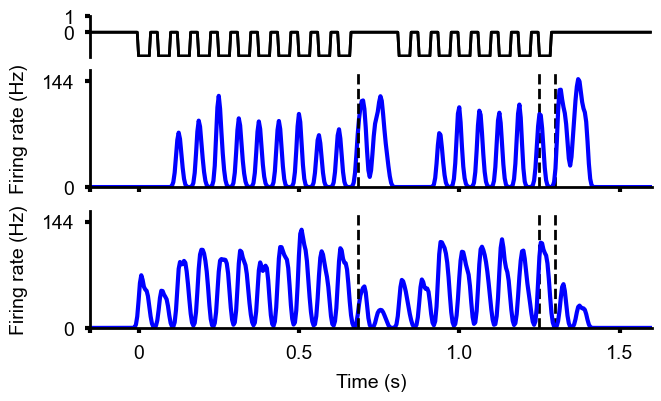

In [69]:
#Plot 16Hz OSR with middle of the sequence omission
#Colours need adjusting


fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1+1
x=200
plot_osr(ors_query_mid_16hz, intesity_ax, 0.6, 21, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_mid_16hz, intesity_ax, 0.6, 393, d, firing2_ax)
firing1_ax.plot([x, x], [0, 1], "--", c="black", linewidth=2)
firing2_ax.plot([x, x], [0, 1], "--", c="black", linewidth=2)
plt.savefig(f"{root}/figures/supp/mid_16hz.svg", format="svg", transparent=False, bbox_inches="tight")

## Response latency to period relationship

In [70]:
#Run OSR stimuli at different rates, with recurrent connections ablated or not ablated

osr_query_8hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=8, middle_omission=False)
osr_query_12hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=12, middle_omission=False)
osr_query_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=False)
osr_query_20hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=20, middle_omission=False)
osr_query_ablate_8hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=8, middle_omission=False, ablate_recurrence=True)
osr_query_ablate_12hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=12, middle_omission=False, ablate_recurrence=True)
osr_query_ablate_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=False, ablate_recurrence=True)
osr_query_ablate_20hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=20, middle_omission=False, ablate_recurrence=True)
osr_query_mid_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=True)


In [88]:
#Get timing of last stimulus response and first OSR for every unit

plot_figs = False

lfp_list = np.full((400, 4), np.nan)#first flash peak
lfp_list = np.full((400, 4), np.nan)#last flash peak
osr_list = np.full((400, 4), np.nan)#first omission response
lfp_list_ablate = np.full((400, 4), np.nan)
lfp_list_ablate = np.full((400, 4), np.nan)
osr_list_ablate = np.full((400, 4), np.nan)
ffp_list_input = np.full((400, 4), np.nan)
lfp_list_input = np.full((400, 4), np.nan)
osr_list_input = np.full((400, 4), np.nan)

peak_delay = 2
match_firing_version = False
valid_units = 0
valid_units_ablate = 0
valid_units_input = 0
valid_units_12Hz = 0
valid_units_ablate_12Hz = 0
for n in range(400):
    if (n in osr_query_8hz.responsive_idx) or (n in osr_query_12hz.responsive_idx) or (n in osr_query_8hz.responsive_idx) and (n in osr_query_8hz.responsive_idx):
        x=200
        
        #Firing rates
        if plot_figs:
            fig = plt.figure(constrained_layout=True, figsize=(1.3*6, 1.3*2))
            spec = gridspec.GridSpec(nrows=8, ncols=1, height_ratios=[0.2, 1, 0.2, 1, 0.2, 1, 0.2, 1], hspace=0.1, figure=fig)
            intesity1_ax = fig.add_subplot(spec[0])
            plt.title('Unit: n=%i' %n)
            firing1_ax = fig.add_subplot(spec[1]) 
            d=44-15+9+1+4-20
            last_flash_onset = plot_osr(osr_query_8hz, intesity1_ax, 1, n, d, firing1_ax)            
        else:
            last_flash_onset = get_last_flash_onset(osr_query_8hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_8hz.firing_rate[n])
        final_peaks1 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks1.size > 1:
            last_flash_peak1 = peaks[final_peaks1[0]]/4.33
            first_osr_peak1 = peaks[final_peaks1[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing1_ax.plot([last_flash_peak1, first_osr_peak1],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak1 = np.nan
            first_osr_peak1 = np.nan
            
        if plot_figs:
            intesity2_ax = fig.add_subplot(spec[2])
            firing2_ax = fig.add_subplot(spec[3]) 
            d=44-15+9+1+3-10
            last_flash_onset = plot_osr(osr_query_12hz, intesity2_ax, 1, n, d, firing2_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_12hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_12hz.firing_rate[n])
        final_peaks2 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks2.size > 1:
            valid_units_12Hz += 1
            last_flash_peak2 = peaks[final_peaks2[0]]/4.33
            first_osr_peak2 = peaks[final_peaks2[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing2_ax.plot([last_flash_peak2, first_osr_peak2],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak2 = np.nan
            first_osr_peak2 = np.nan
            
        if plot_figs:   
            intesity3_ax = fig.add_subplot(spec[4])
            firing3_ax = fig.add_subplot(spec[5]) 
            d=44-15+9+1+2-4
            last_flash_onset = plot_osr(osr_query_16hz, intesity3_ax, 1, n, d, firing3_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_16hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_16hz.firing_rate[n])
        final_peaks3 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks3.size > 1:
            last_flash_peak3 = peaks[final_peaks3[0]]/4.33
            first_osr_peak3 = peaks[final_peaks3[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing3_ax.plot([last_flash_peak3, first_osr_peak3],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak3 = np.nan
            first_osr_peak3 = np.nan
            
        if plot_figs:
            intesity4_ax = fig.add_subplot(spec[6])
            firing4_ax = fig.add_subplot(spec[7]) 
            d=44-15+9+1+1
            last_flash_onset = plot_osr(osr_query_20hz, intesity4_ax, 1, n, d, firing4_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_20hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_20hz.firing_rate[n])
        final_peaks4 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks4.size > 1:
            last_flash_peak4 = peaks[final_peaks4[0]]/4.33
            first_osr_peak4 = peaks[final_peaks4[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing4_ax.plot([last_flash_peak4, first_osr_peak4],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak4 = np.nan
            first_osr_peak4 = np.nan
            
        if (final_peaks1.size > 1) or (final_peaks2.size > 1) or (final_peaks3.size > 1) or (final_peaks4.size > 1):
            lfp_list[valid_units,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
            osr_list[valid_units,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
            isvalid = True
            valid_units += 1
        else:
            isvalid = False
            
        
        #Firing rate, ablated recurrency
        if plot_figs:
            fig = plt.figure(constrained_layout=True, figsize=(1.3*6, 1.3*2))
            spec = gridspec.GridSpec(nrows=8, ncols=1, height_ratios=[0.2, 1, 0.2, 1, 0.2, 1, 0.2, 1], hspace=0.1, figure=fig)
            intesity1_ax = fig.add_subplot(spec[0])
            plt.title('Unit: n=%i' %n)
            firing1_ax = fig.add_subplot(spec[1]) 
            d=44-15+9+1+4-20
            last_flash_onset = plot_osr(osr_query_ablate_8hz, intesity1_ax, 1, n, d, firing1_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_ablate_8hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_ablate_8hz.firing_rate[n])
        final_peaks1 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks1.size > 1:
            last_flash_peak1 = peaks[final_peaks1[0]]/4.33
            first_osr_peak1 = peaks[final_peaks1[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing1_ax.plot([last_flash_peak1, first_osr_peak1],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak1 = np.nan
            first_osr_peak1 = np.nan
            
        if plot_figs:    
            intesity2_ax = fig.add_subplot(spec[2])
            firing2_ax = fig.add_subplot(spec[3]) 
            d=44-15+9+1+3-10
            last_flash_onset = plot_osr(osr_query_ablate_12hz, intesity2_ax, 1, n, d, firing2_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_ablate_12hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_ablate_12hz.firing_rate[n])
        final_peaks2 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks2.size > 1:
            valid_units_ablate_12Hz += 1
            last_flash_peak2 = peaks[final_peaks2[0]]/4.33
            first_osr_peak2 = peaks[final_peaks2[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing2_ax.plot([last_flash_peak2, first_osr_peak2],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak2 = np.nan
            first_osr_peak2 = np.nan
        
        if plot_figs:
            intesity3_ax = fig.add_subplot(spec[4])
            firing3_ax = fig.add_subplot(spec[5]) 
            d=44-15+9+1+2-4
            last_flash_onset = plot_osr(osr_query_ablate_16hz, intesity3_ax, 1, n, d, firing3_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_ablate_16hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_ablate_16hz.firing_rate[n])
        final_peaks3 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks3.size > 1:
            last_flash_peak3 = peaks[final_peaks3[0]]/4.33
            first_osr_peak3 = peaks[final_peaks3[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing3_ax.plot([last_flash_peak3, first_osr_peak3],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak3 = np.nan
            first_osr_peak3 = np.nan
        
        if plot_figs:
            intesity4_ax = fig.add_subplot(spec[6])
            firing4_ax = fig.add_subplot(spec[7]) 
            d=44-15+9+1+1
            last_flash_onset = plot_osr(osr_query_ablate_20hz, intesity4_ax, 1, n, d, firing4_ax)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_ablate_20hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_ablate_20hz.firing_rate[n])
        final_peaks4 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks4.size > 1:
            last_flash_peak4 = peaks[final_peaks4[0]]/4.33
            first_osr_peak4 = peaks[final_peaks4[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing4_ax.plot([last_flash_peak4, first_osr_peak4],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak4 = np.nan
            first_osr_peak4 = np.nan
            
        if match_firing_version:
            if isvalid:
                lfp_list_ablate[valid_units,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
                osr_list_ablate[valid_units,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
        else:
            if (final_peaks1.size > 1) or (final_peaks2.size > 1) or (final_peaks3.size > 1) or (final_peaks4.size > 1):
                lfp_list_ablate[valid_units_ablate,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
                osr_list_ablate[valid_units_ablate,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
                valid_units_ablate += 1
            
        #Input current
        if plot_figs:
            fig = plt.figure(constrained_layout=True, figsize=(1.3*6, 1.3*2))
            spec = gridspec.GridSpec(nrows=8, ncols=1, height_ratios=[0.2, 1, 0.2, 1, 0.2, 1, 0.2, 1], hspace=0.1, figure=fig)
            intesity1_ax = fig.add_subplot(spec[0])
            plt.title('Unit: n=%i' %n)
            firing1_ax = fig.add_subplot(spec[1]) 
            d=44-15+9+1+4-20
            last_flash_onset = plot_osr(osr_query_8hz, intesity1_ax, 1, n, d, firing1_ax, input_current=True)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_8hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_8hz.smooth_input_current[n])
        final_peaks1 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks1.size > 1:
            last_flash_peak1 = peaks[final_peaks1[0]]/4.33
            first_osr_peak1 = peaks[final_peaks1[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing1_ax.plot([last_flash_peak1, first_osr_peak1],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak1 = np.nan
            first_osr_peak1 = np.nan
        
        if plot_figs:
            intesity2_ax = fig.add_subplot(spec[2])
            firing2_ax = fig.add_subplot(spec[3]) 
            d=44-15+9+1+3-10
            last_flash_onset = plot_osr(osr_query_12hz, intesity2_ax, 1, n, d, firing2_ax, input_current=True)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_12hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_12hz.smooth_input_current[n])
        final_peaks2 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks2.size > 1:
            last_flash_peak2 = peaks[final_peaks2[0]]/4.33
            first_osr_peak2 = peaks[final_peaks2[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing2_ax.plot([last_flash_peak2, first_osr_peak2],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak2 = np.nan
            first_osr_peak2 = np.nan
            
        if plot_figs:
            intesity3_ax = fig.add_subplot(spec[4])
            firing3_ax = fig.add_subplot(spec[5]) 
            d=44-15+9+1+2-4
            last_flash_onset = plot_osr(osr_query_16hz, intesity3_ax, 1, n, d, firing3_ax, input_current=True)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_16hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_16hz.smooth_input_current[n])
        final_peaks3 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks3.size > 1:
            last_flash_peak3 = peaks[final_peaks3[0]]/4.33
            first_osr_peak3 = peaks[final_peaks3[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing3_ax.plot([last_flash_peak3, first_osr_peak3],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak3 = np.nan
            first_osr_peak3 = np.nan
            
        if plot_figs:
            intesity4_ax = fig.add_subplot(spec[6])
            firing4_ax = fig.add_subplot(spec[7]) 
            d=44-15+9+1+1
            last_flash_onset = plot_osr(osr_query_20hz, intesity4_ax, 1, n, d, firing4_ax, input_current=True)
        else:
            last_flash_onset = get_last_flash_onset(osr_query_20hz,'ms')
            
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_20hz.smooth_input_current[n])
        final_peaks4 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks4.size > 1:
            last_flash_peak4 = peaks[final_peaks4[0]]/4.33
            first_osr_peak4 = peaks[final_peaks4[1]]/4.33
            latencycolor = "red"
            if plot_figs:
                firing4_ax.plot([last_flash_peak4, first_osr_peak4],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak4 = np.nan
            first_osr_peak4 = np.nan
            
        if match_firing_version:
            if isvalid:
                lfp_list_input[valid_units,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
                osr_list_input[valid_units,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
        else:
            if (final_peaks1.size > 1) or (final_peaks2.size > 1) or (final_peaks3.size > 1) or (final_peaks4.size > 1):
                lfp_list_input[valid_units_input,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
                osr_list_input[valid_units_input,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
                valid_units_input += 1


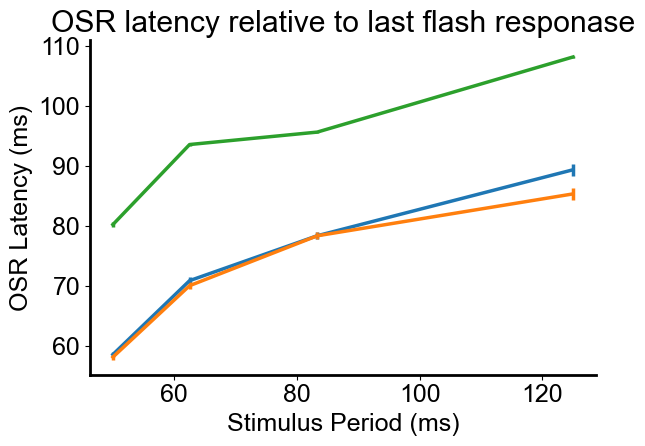

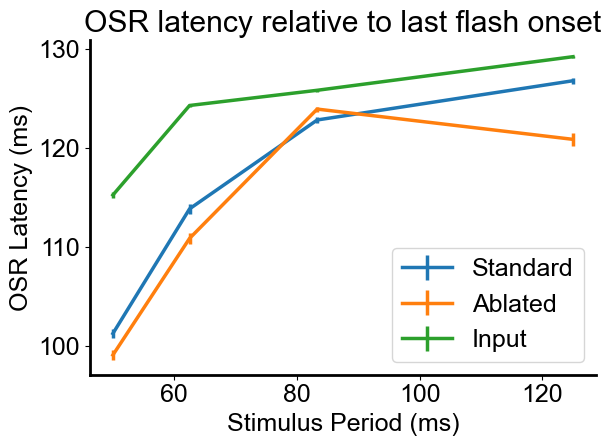

In [72]:
#plot mean population OSR latency relative last flash responase peak against stimulus period,
#for standard model, model with ablated recurrency, and feedforward input

#plot mean population OSR latency relative to last flash onset against stimulus period,
#for standard model, model with ablated recurrency, and feedforward input

import matplotlib.pyplot as plt


# Global plot style settings
plt.rcParams.update({
    'font.size': 18,          # 2x default font size (12 → 24)
    'lines.linewidth': 2.5,   # 2x default line width (~1.25 → 2.5)
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2.0     # make bottom/left axes thicker
})

last_flash_onset1 = get_last_flash_onset(osr_query_8hz, 'ms')
last_flash_onset2 = get_last_flash_onset(osr_query_12hz, 'ms')
last_flash_onset3 = get_last_flash_onset(osr_query_16hz, 'ms')
last_flash_onset4 = get_last_flash_onset(osr_query_20hz, 'ms')
lfo = [last_flash_onset4, last_flash_onset3, last_flash_onset2, last_flash_onset1]

lfp_list = lfp_list[:valid_units,:]
osr_list = osr_list[:valid_units,:]


if match_firing_version:
    lfp_list_ablate = lfp_list_ablate[:valid_units,:]
    osr_list_ablate = osr_list_ablate[:valid_units,:]
    lfp_list_input = lfp_list_input[:valid_units,:]
    osr_list_input = osr_list_input[:valid_units,:]
else:
    lfp_list_ablate = lfp_list_ablate[:valid_units_ablate,:]
    osr_list_ablate = osr_list_ablate[:valid_units_ablate,:]
    lfp_list_input = lfp_list_input[:valid_units_input,:]
    osr_list_input = osr_list_input[:valid_units_input,:]

    
plt.figure()
latencies = np.fliplr(osr_list - lfp_list)*4.333
meanlatency = np.nanmean(latencies,axis=0)
semlatency = np.nanstd(latencies,axis=0)/np.sum(~np.isnan(latencies),axis=0)
periods = np.array([50, 62.5, 83.3, 125])
plt.errorbar(periods,meanlatency,semlatency)

latencies_ablate = np.fliplr(osr_list_ablate - lfp_list_ablate)*4.333
meanlatency_ablate = np.nanmean(latencies_ablate,axis=0)
semlatency_ablate = np.nanstd(latencies_ablate,axis=0)/np.sum(~np.isnan(latencies_ablate),axis=0)
plt.errorbar(periods,meanlatency_ablate,semlatency_ablate)

latencies_input = np.fliplr(osr_list_input - lfp_list_input)*4.333
meanlatency_input = np.nanmean(latencies_input,axis=0)
semlatency_input = np.nanstd(latencies_input,axis=0)/np.sum(~np.isnan(latencies_input),axis=0)
plt.errorbar(periods,meanlatency_input,semlatency_input)
plt.xlabel("Stimulus Period (ms)")
plt.ylabel("OSR Latency (ms)")
plt.title("OSR latency relative to last flash responase")
plt.tight_layout()


plt.figure()
latencies = np.fliplr(osr_list - last_flash_onset1/4.333)*4.333
meanlatency = np.nanmean(latencies,axis=0)
semlatency = np.nanstd(latencies,axis=0)/np.sum(~np.isnan(latencies),axis=0)
periods = np.array([50, 62.5, 83.3, 125])
plt.errorbar(periods,meanlatency,semlatency)

latencies_ablate = np.fliplr(osr_list_ablate - last_flash_onset1/4.333)*4.333
meanlatency_ablate = np.nanmean(latencies_ablate,axis=0)
semlatency_ablate = np.nanstd(latencies_ablate,axis=0)/np.sum(~np.isnan(latencies_ablate),axis=0)
plt.errorbar(periods,meanlatency_ablate,semlatency_ablate)

latencies_input = np.fliplr(osr_list_input  - last_flash_onset1/4.333)*4.333
meanlatency_input = np.nanmean(latencies_input,axis=0)
semlatency_input = np.nanstd(latencies_input,axis=0)/np.sum(~np.isnan(latencies_input),axis=0)
plt.errorbar(periods,meanlatency_input,semlatency_input)
plt.xlabel("Stimulus Period (ms)")
plt.ylabel("OSR Latency (ms)")
plt.legend(["Standard", "Ablated", "Input"], loc="best")
plt.title("OSR latency relative to last flash onset")
plt.tight_layout()

In [73]:
active_units = 287
print(100*valid_units/active_units)
print(100*valid_units_ablate/active_units)
print(100*valid_units_12Hz/active_units)
print(100*valid_units_ablate_12Hz/active_units)

19.51219512195122
19.860627177700348
16.027874564459932
16.37630662020906


## Inspection of spatiotemporal RFs of OSR units

In [74]:
ors_query = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300)

In [75]:
enc_model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_0_8")
pred_model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")
enc_rf_query = analysis.RFQuery(root, enc_model)
pred_rf_query = analysis.RFQuery(root, pred_model)

INFO:util:Processing batch 0 out of 4...
INFO:util:Processing batch 1 out of 4...
INFO:util:Processing batch 2 out of 4...
INFO:util:Processing batch 3 out of 4...
INFO:gaussian:CC criteria exclusion 400
INFO:gaussian:Location criteria exclusion 38
INFO:gaussian:Envelope criteria exclusion 12
INFO:util:Processing batch 0 out of 4...
INFO:util:Processing batch 1 out of 4...
INFO:util:Processing batch 2 out of 4...
INFO:util:Processing batch 3 out of 4...
INFO:gaussian:CC criteria exclusion 224
INFO:gaussian:Location criteria exclusion 38
INFO:gaussian:Envelope criteria exclusion 12


In [76]:
def plot_spatiotemporal_rf(strf, i, subspec, fig):
    strf = strf.cpu().detach()
    maxv = strf.abs().max()
    
    for j in range(3, len(strf)):
        ax = plt.Subplot(fig, subspec[i, j])
        fig.add_subplot(ax)
        im = ax.imshow(strf[j], cmap="bwr", vmin=-maxv, vmax=maxv)
        ax.axis("off")

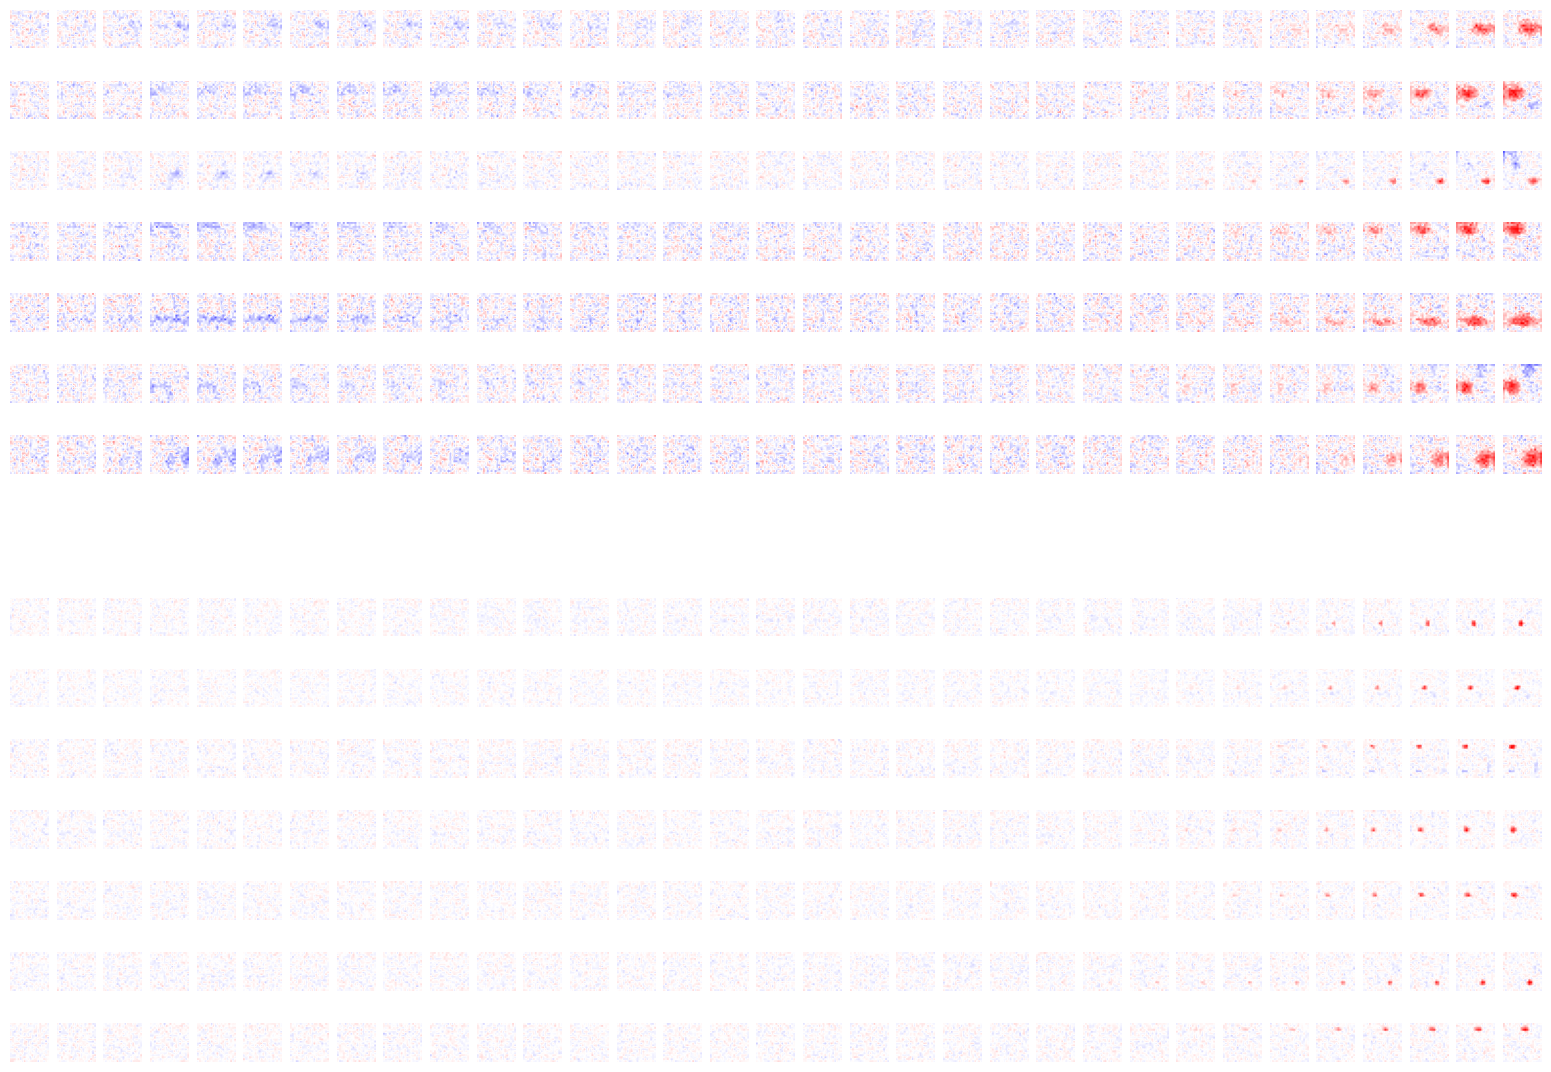

In [85]:
l = 30
fig = plt.figure(constrained_layout=True, figsize=(30, 14))
spec = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[1, 1], hspace=0.2)
top_spec = gridspec.GridSpecFromSubplotSpec(7, 50, subplot_spec=spec[0], hspace=0.1)
bottom_spec = gridspec.GridSpecFromSubplotSpec(7, 50, subplot_spec=spec[1], hspace=0.1)

plot_spatiotemporal_rf(pred_rf_query.og_strfs[8, :], 0, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[17, :], 1, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[21, :], 2, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[29, :], 3, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[47, :], 4, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[79, :], 5, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[89, :], 6, top_spec, fig)
#plot_spatiotemporal_rf(pred_rf_query.og_strfs[178, :], 7, top_spec, fig)

plot_spatiotemporal_rf(enc_rf_query.og_strfs[2, :], 0, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[5, :], 1, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[35, :], 2, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[56, :], 3, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[70, :], 4, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[89, :], 5, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[127, :], 6, bottom_spec, fig)
#plot_spatiotemporal_rf(enc_rf_query.og_strfs[359, :], 7, bottom_spec, fig)

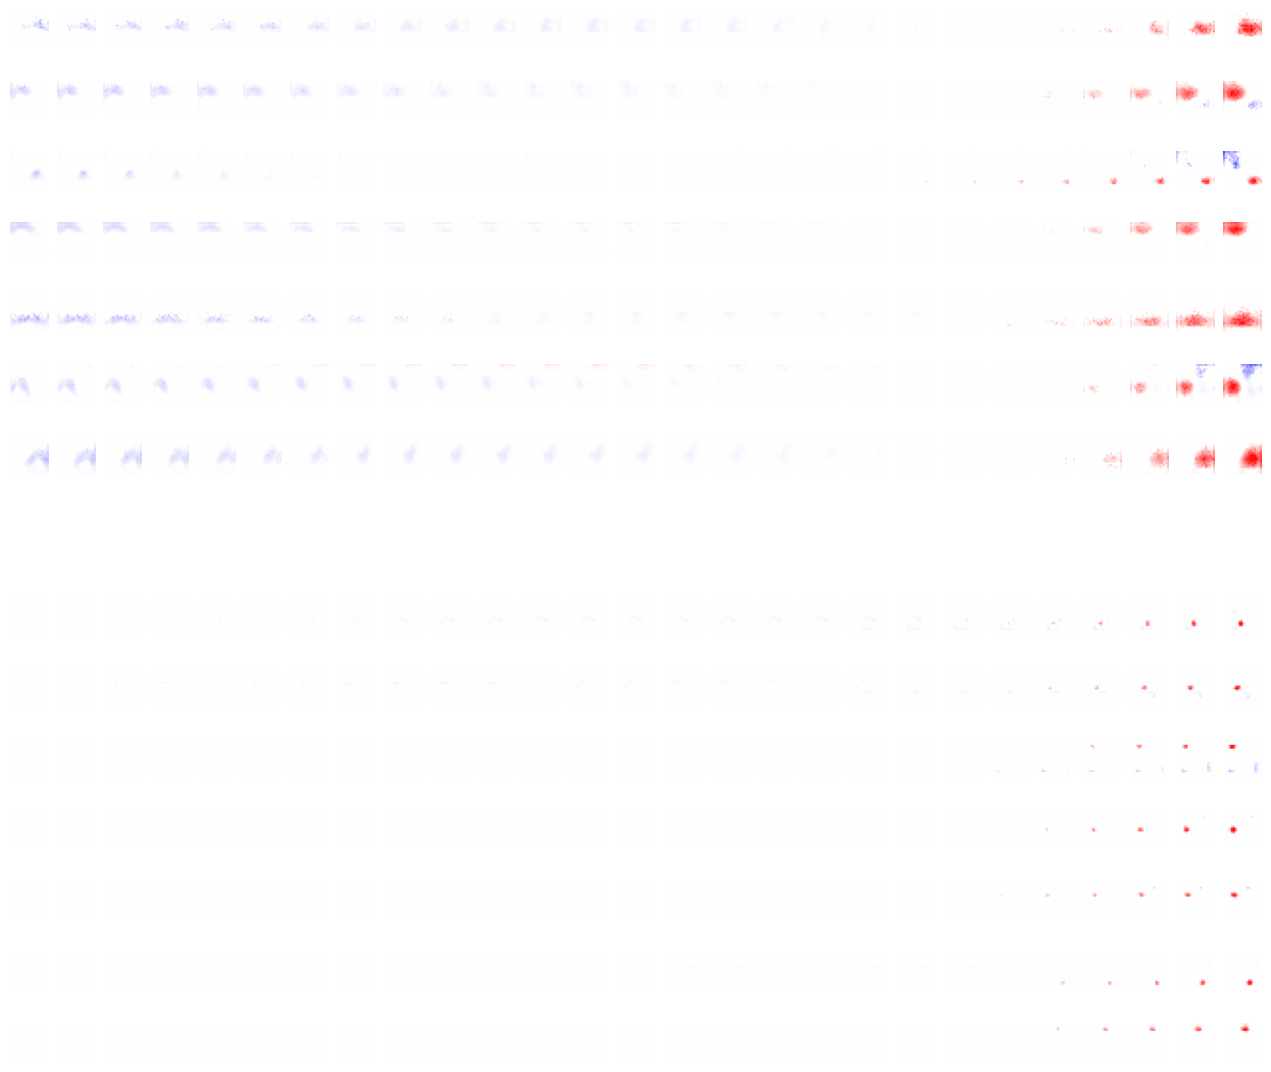

In [86]:
def extract_component_matrices(W: torch.Tensor, index: int):
    """
    Extracts the `index`-th component from a weight tensor W of shape [N, 1, C, H, W]
    and returns a tensor of shape [C, H, W].

    Args:
        W (torch.Tensor): Input tensor of shape [N, 1, C, H, W]
        index (int): Index of the component to extract (0 <= index < N)

    Returns:
        torch.Tensor: Tensor of shape [C, H, W]
    """
    if not (0 <= index < W.shape[0]):
        raise IndexError(f"Index {index} is out of bounds for first dimension of size {W.shape[0]}")
    
    return W[index].squeeze(0)  # shape: [C, H, W]

W = pred_model._encoder_weight
W2 = enc_model._encoder_weight

l = 30
fig = plt.figure(constrained_layout=True, figsize=(30, 14))
spec = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[1, 1], hspace=0.2)
top_spec = gridspec.GridSpecFromSubplotSpec(7, 50, subplot_spec=spec[0], hspace=0.1)
bottom_spec = gridspec.GridSpecFromSubplotSpec(7, 50, subplot_spec=spec[1], hspace=0.1)

plot_spatiotemporal_rf(extract_component_matrices(W,8), 0, top_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,17), 1, top_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,21), 2, top_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,29), 3, top_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,47), 4, top_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,79), 5, top_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W,89), 6, top_spec, fig)
#plot_spatiotemporal_rf(extract_component_matrices(W,178), 7, top_spec, fig)

plot_spatiotemporal_rf(extract_component_matrices(W2, 2), 0, bottom_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W2, 5), 1, bottom_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W2, 35), 2, bottom_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W2, 56), 3, bottom_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W2, 70), 4, bottom_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W2, 89), 5, bottom_spec, fig)
plot_spatiotemporal_rf(extract_component_matrices(W2, 127), 6, bottom_spec, fig)
#plot_spatiotemporal_rf(extract_component_matrices(W2, 359), 7, bottom_spec, fig)
